# Animations in loopforest package

This is a quick showcase of the plotting functionalities in the loopforest package. The functions to create animiations are methods of the PersistenceForest class.

In [1]:
from loopforest import PersistenceForest

### Example point cloud

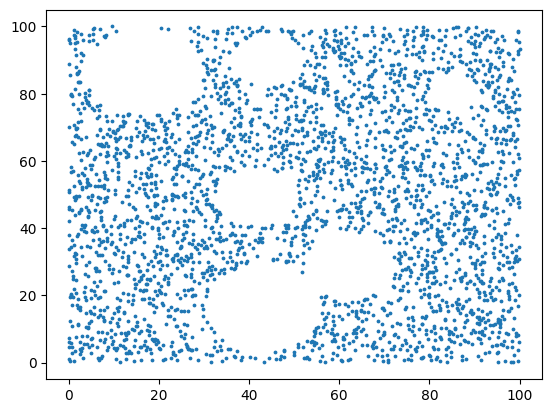

In [2]:
import matplotlib.pyplot as plt

from point_cloud_sampling import sample_points_without_balls

points_with_6_holes = sample_points_without_balls(3000, dim=2, num_discs=6, radius_range=[0.05,0.15], seed=5) * 100

plt.scatter(points_with_6_holes[:,0],points_with_6_holes[:,1], s=3)
plt.show()

### Compute PersistenceForest

We now compute the PersistenceForest object from the point cloud. This is the fundamental object of this package and it contains all functionalities, including animations.

In [3]:
forest_6_holes = PersistenceForest(points_with_6_holes)

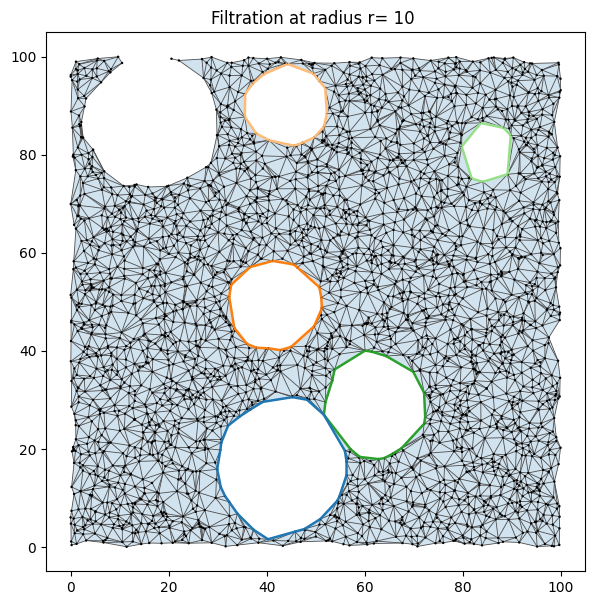

<Axes: title={'center': 'Filtration at radius r= 10 '}>

In [4]:
# a simple plotting method of PersistenceForest
forest_6_holes.plot_at_filtration(filt_val=10, coloring="bars")

## Generate Barcode Animation

In [5]:
#set up folder for saving animations
from pathlib import Path

Path("example_figures").mkdir(exist_ok=True)

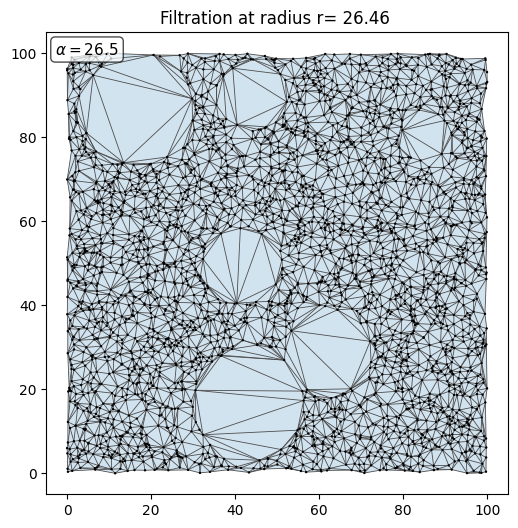

In [6]:
anim, fig = forest_6_holes.animate_filtration(
    "example_figures/6holes_random_points_default.mp4",
)

In [7]:
anim, fig = forest_6_holes.animate_filtration(
    "example_figures/6holes_random_points_barcode_bar-coloring.mp4",
    fps=25,
    total_figsize=(11,5),
    frames=300,
    t_min =0,
    t_max = 28,
    dpi=300,
    coloring = "bars",
    plot_kwargs=dict(vertex_size=3, coloring="bars", title = "Alpha Filtration", show_cycles=True, linewidth_cycle=1.8),
    with_barcode=True,
    barcode_kwargs=dict(min_bar_length = 0.5, max_bars = 30, coloring = "bars")
)

TypeError: PersistenceForest.animate_filtration() got an unexpected keyword argument 'total_figsize'

The coloring "bars" assigns an arbitrary color to each bar in the barcode and its corresponding cycle representatives. The coloring "forest" colors the bars and cycle representatives depending on whether they are contained in the same tree in the persistence forest.

In both cases, the color map is saved in the PersistenceForest object and will be consistent across plots and animations.

## Generate Animation of Barcode Measurement Functional

We now showcase how we can plot how measurements of cycle representatives like length change along a bar in the barcode.

In [ ]:
from point_cloud_sampling import sample_noisy_star

star = sample_noisy_star(1000, spikes=5, amplitude=0.4,radius=0.62, noise_std=0.02)*10

forest_star = PersistenceForest(star)
ax = forest_star.plot_at_filtration(0, show=False)
ax.set_title("Star point cloud")
plt.show()

We first import the function signed_chain_edge_length which maps each a (signed) cycle represnetatives onto its length. The file "cycle_rep_vectorisation.py" also contains similar functions for computing area, excess curvature and circularity.

In [ ]:
from loopforest.cycle_rep_vectorisations import signed_chain_edge_length

We can now plot the values of this function along the longest bar in the barcode.

In [ ]:
forest_star.animate_barcode_measurement(cycle_func=signed_chain_edge_length, 
                                        signed=False, 
                                        frames =300,
                                        plot_kwargs=dict(vertex_size=3, coloring="forest", title = "Alpha Filtration", linewidth_cycle=1.7),
                                        measurement_kwargs=dict(y_range=(0,85), show_baseline=False, title="Length of Cycle Representative"),
                                        filename="example_figures/star_edge-length_measurement.mp4")

# A 3d examples

In [3]:
import shutil
import numpy as np
from loopforest.PersistenceForest import PersistenceForest

# ---- 3D test cloud: noisy sphere ----
rng = np.random.default_rng(7)
n = 220
phi = rng.uniform(0.0, 2.0 * np.pi, n)
u = rng.uniform(-1.0, 1.0, n)
theta = np.arccos(u)
r = 1.0 + 0.04 * rng.normal(size=n)

x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)
points = np.column_stack([x, y, z])

forest = PersistenceForest(points)

# ---- MP4 export (browser-free: matplotlib + ffmpeg) ----
if shutil.which("ffmpeg") is None:
    raise RuntimeError("ffmpeg is required for MP4 export. Install it first.")





In [4]:
forest.animate_filtration(
    filename="example_figures/noisy_sphere_filtration_orbit.mp4",
    format="mp4",
    with_barcode=True,
    fps=20,
    frames=120,
    coloring="forest",
    show_cycles=True,
    signed=False,
    min_bar_length=0.05,
    show_complex=True,
    complex_opacity=0.01,
    cycle_opacity=0.9,
    vertex_size=1.0,
    width=1400,
    height=700,
    camera_mode="fixed",     # try "fixed" as well
    camera_eye=(22, -55),    # (elev, azim)
)


'example_figures/noisy_sphere_filtration_orbit.mp4'

In [ ]:
# ---- Optional interactive HTML export (Plotly path) ----
forest.animate_filtration(
    filename="example_figures/noisy_sphere_filtration_interactive.html",
    format="html",
    frames=100,
    coloring="forest",
    show_cycles=True,
    min_bar_length=0.05,
    show_complex=True,
    complex_opacity=0.18,
    cycle_opacity=0.60,
    vertex_size=4.0,
    width=1000,
    height=700,
)